# Work flow
----------------------------------------------------------------------
## 1. Generate spike trains
## 2. Generate calcium dynamic from spike trains with multiple noise level
## 3. Perform spike deconvolution and compare the result with original spike trains
----------------------------------------------------------------------

# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from oasis.functions import gen_data, gen_sinusoidal_data, deconvolve, estimate_parameters
from oasis.plotting import simpleaxis
from oasis.oasis_methods import oasisAR1, oasisAR2
from suite2p.extraction import dcnv
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import find_peaks
import os
import glob
import h5py
import warnings
warnings.simplefilter('ignore')

In [2]:
from oasis.functions import gen_data, gen_sinusoidal_data, deconvolve, estimate_parameters
from oasis.plotting import simpleaxis
from oasis.oasis_methods import oasisAR1, oasisAR2

# Load actual calcium imaging data

In [3]:
dF_F_path = glob.glob(os.getcwd()+'/data/dF_F.mat')[0]
ROI_metrics_path = glob.glob(os.getcwd()+'/data/ROI_metrics.mat')[0]

In [4]:
with h5py.File(dF_F_path, 'r') as f:
    # Navigate to your dataset "dF_F"
    cell_data = f["dF_F"]

    # Create an empty list to collect numpy arrays
    dF_F = []

    # Loop through the references in the cell_data
    for ref in cell_data:
        # Dereference the object reference
        ref_data = f[ref[0]]
        
        # Convert to numpy array and append to list
        dF_F.append(np.array(ref_data))

    # Convert list of arrays to a single numpy array
    dF_F = np.array(dF_F)

In [5]:
with h5py.File(ROI_metrics_path, 'r') as f:
    ROI_metircs_h5 = f["ROI_metrics"]
    ROI_metrics={}
    for i in ROI_metircs_h5.keys():
        ROI_metrics.update({i:np.array(list(ROI_metircs_h5[i]))})

In [6]:
fs=15.2 # frame per second
CellUse = np.where(ROI_metrics['CellUse'][0]==1)[0]
cell_dF_F = dF_F[:,:,CellUse]
cell_centroid = ROI_metrics['Centroid'][:,CellUse].T
cell_dF_F = cell_dF_F.reshape(-1, cell_dF_F.shape[2]).T # Concatenate multiple recording blocks
time = np.arange(0,cell_dF_F.shape[1], 1)/fs

# Simulation

In [7]:
def generate_spikes(rate, duration, sf_ephys):
    """
    Generate spikes based on a Poisson process.
    
    Parameters:
    - rate: average rate of spikes per second.
    - duration: duration of the spike train in seconds.
    - sf_ephys: sampling frequency of spiking activity
    
    Returns:
    - spike_times: array of spike times.
    """
    np.random.seed(0)
    mean_interval = 1.0 / rate
    times = np.random.exponential(scale=mean_interval, size=int(rate * duration * 1.5))
    spike_times = np.cumsum(times)
    spike_times = spike_times[spike_times < duration]
    spike_times = (spike_times*sf_ephys).astype('int')
    t_ephys=np.arange(0, duration, 1/sf_ephys)
    return t_ephys,spike_times

In [8]:
def simulate_calcium_dynamics(spike_times, duration, sf_imaging=15.2, tau_rise=0.2, tau_decay=1.0, A=0.5, Ca_rest=0.1, sigma=0.1, eta=0.01):
    """
    Simulate calcium dynamics with noise based on spike times.
    
    Parameters:
    - spike_times: array of spike times.
    - duration: duration of the simulation in seconds.
    - sf_imaging: sampling frequency of calcium signal.
    - tau_rise: rise time constant of the calcium signal.
    - tau_decay: decay time constant of the calcium signal.
    - A: amplitude of calcium increase per spike.
    - Ca_rest: resting calcium concentration.
    - sigma: standard deviation of the measurement noise.
    - eta: scale of the evolution noise.
    
    Returns:
    - t: array of time points.
    - Ca: array of noisy calcium concentrations over time.
    """
    dt = 1 / sf_imaging
    t_imaging = np.arange(0, duration, dt)
    Ca = np.zeros_like(t_imaging) + Ca_rest
    B = np.zeros_like(t_imaging)  # Drifting baseline B(t)
    
    # Simulate the spikes and calcium concentration
    for spike_time in spike_times:
        spike_idx = int(spike_time / dt)
        t_since_spike = t_imaging[spike_idx:] - t_imaging[spike_idx]
        # Ca[spike_idx:] += A * (1 - np.exp(-t_since_spike / tau_rise)) * np.exp(-t_since_spike / tau_decay)
        Ca[spike_idx:] += A *Ca_rest* (np.exp(-t_since_spike / tau_decay) - np.exp(-t_since_spike / tau_rise))
        # Ca[spike_idx:] += A *Ca_rest* np.exp(-(t_imaging[spike_idx:] - t_imaging[spike_idx]) / tau)

    # Add evolution noise using Brownian motion
    dW = np.random.normal(0, np.sqrt(dt) * eta * Ca_rest, size=len(t_imaging))
    B += np.cumsum(dW)  # Integrate the Brownian motion over time
    
    # Add measurement noise
    measurement_noise = np.random.normal(0, sigma * Ca_rest, size=len(t_imaging))

    # Combine the calcium signal with noise
    Ca_noisy = Ca + B + measurement_noise
    return t_imaging, Ca_noisy, Ca


In [9]:
def calc_dF_F(F, sf_imaging, win_baseline=60):
    from scipy.ndimage import percentile_filter
    #calculate baseline
    Fbase = percentile_filter(F, percentile=8, size=int(win_baseline*sf_imaging), axes=1)
    #calculate dF/F
    Fcorr = F-Fbase
    dF_F = Fcorr/Fbase
    return Fcorr, dF_F

In [167]:
# Parameters for spike train generation
np.random.seed(0)
N_Neuron = 100 # Number of neurons
rate=np.random.uniform(.005, .05, N_Neuron) # Firing rate distribution
duration=500 #simulation duration in seconds
sf_ephys=10000 #sampling frequency of spiking

# Generate spike trains for N_Neurons
Spike_train = np.zeros([N_Neuron,int(duration*sf_ephys)])
for i in range(N_Neuron):
    t_ephys, spike_times=generate_spikes(rate=rate[i], duration=duration, sf_ephys=sf_ephys)
    Spike_train[i,spike_times]=1

# Generate calcium dynamics based on spike trains with different sigmas
sf_imaging=fs
sigmas = [0,0.1,0.2,0.3]
# sigmas = [0,0.1]
Ca_dynamics_all = {}
pure_Ca_dynamics_all = {}
for v in sigmas:
    Ca_dynamics = np.zeros([N_Neuron,int(duration*sf_imaging)])
    pure_Ca_dynamics = np.zeros([N_Neuron,int(duration*sf_imaging)])
    for i in range(N_Neuron):
        t_imaging, Ca_dynamics[i], pure_Ca_dynamics[i] = simulate_calcium_dynamics(np.where(Spike_train[i])[0]/sf_ephys, 
                                                              duration=duration, sf_imaging=sf_imaging, tau_rise=0.1,
                                                              tau_decay=10, A=1, Ca_rest=1000, sigma=v, eta=0.01)
    Ca_dynamics_all.update({v:Ca_dynamics})
    pure_Ca_dynamics_all.update({v:pure_Ca_dynamics})

In [168]:
Fcorr_sim_all={} # baseline corrected F value
dF_F_sim_all={} # baseline corrected dF/F0 value
for i in Ca_dynamics_all.keys():
    Fcorr_sim, dF_F_sim=calc_dF_F(Ca_dynamics_all[i], sf_imaging, win_baseline=60)
    Fcorr_sim_all.update({i:Fcorr_sim})
    dF_F_sim_all.update({i:dF_F_sim})

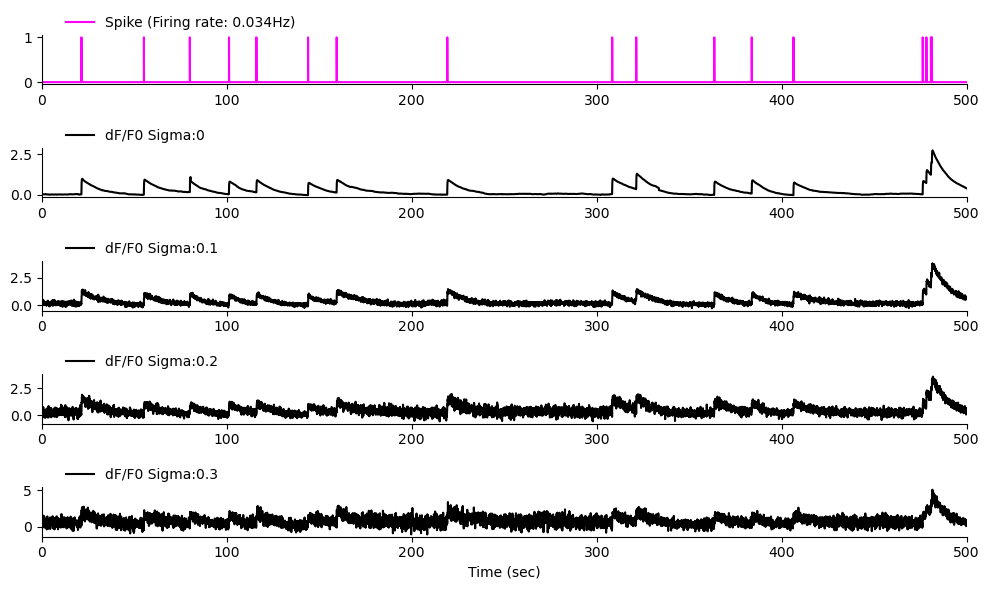

In [169]:
# Plot example neuron
Cell_id=1
plt.figure(figsize=(10,6), tight_layout=True)
plt.subplot(len(dF_F_sim_all.keys())+1,1,1)
plt.plot(t_ephys,Spike_train[Cell_id], color='magenta', label='Spike (Firing rate: '+str(np.sum(Spike_train[Cell_id])/duration)+'Hz)')
plt.xlim(0,duration)
plt.legend(ncol=3, frameon=False, loc=(.02,1));
for i,k in enumerate(dF_F_sim_all.keys()):
    plt.subplot(len(dF_F_sim_all.keys())+1,1,i+2)
    plt.plot(t_imaging,dF_F_sim_all[k][Cell_id], color='black', label='dF/F0 Sigma:'+str(k))
    plt.legend(ncol=3, frameon=False, loc=(.02,1));
    plt.xlim(0,duration)
plt.xlabel('Time (sec)')
sns.despine()

plt.subplots_adjust(wspace=0.4, hspace=0.6)

# Comparison between actual recoding and simulation

## Standarized shot noise level

In [170]:
standarized_noise_level_actual = np.median(abs(np.diff(cell_dF_F,axis=1)*100)/np.sqrt(fs),axis=1)
standarized_noise_level_all={}
for i in dF_F_sim_all.keys():
    standarized_noise_level = np.median(abs(np.diff(dF_F_sim_all[i],axis=1)*100)/np.sqrt(sf_imaging),axis=1)
    standarized_noise_level_all.update({i:standarized_noise_level})

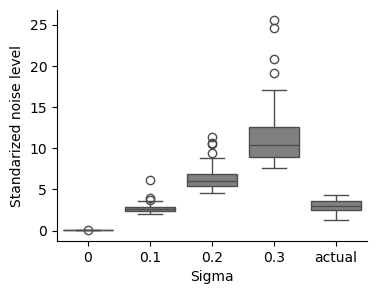

In [171]:
data = {'Key': [],'Value': []}
for key, values in standarized_noise_level_all.items():
    data['Key'].extend([key] * len(values))
    data['Value'].extend(values)
data['Key'].extend(['actual'] * len(standarized_noise_level_actual))
data['Value'].extend(standarized_noise_level_actual)
df = pd.DataFrame(data)
# Seabornを使用してViolin plotを作成
plt.figure(figsize=(4, 3), dpi=100)
sns.boxplot(x='Key', y='Value', data=df, color='gray')
plt.xlabel('Sigma')
plt.ylabel('Standarized noise level')
# plt.yscale('log')
sns.despine()

## Calcium event

In [172]:
def calc_mean_waveform(dF_F_trace, window):
    peaks, _ = find_peaks(dF_F_trace, height=(0,5), distance=200, prominence=0.1, width=10)
    dF_F_peak_waveforms=[]
    num_peak=len(peaks)
    if num_peak<=2:
        num_peak=np.nan
        mean_waveform=np.zeros(window[1]-window[0])
        mean_waveform[:] = np.nan
    else:
        for peak in peaks:
            window=np.array(window)-np.random.choice(3)
            if (peak+window[0]>0)&(peak+window[1]<len(dF_F_trace)):
                dF_F_peak_waveforms.append(dF_F_trace[peak+window[0]:peak+window[1]])
        dF_F_peak_waveforms=np.array(dF_F_peak_waveforms)
        mean_waveform=np.mean(dF_F_peak_waveforms,axis=0)

    return mean_waveform, num_peak

In [173]:
window=[-600,600] # before and after calcium peak (frames)
time_waveform=np.arange(window[0],window[1])/fs
mean_waveforms=[]
num_peaks=[]
for i in range(cell_dF_F.shape[0]):
    mean_waveform, num_peak=calc_mean_waveform(cell_dF_F[i], window)
    mean_waveforms.append(mean_waveform)
    num_peaks.append(num_peak)
mean_waveforms=np.array(mean_waveforms)
num_peaks=np.array(num_peaks)

mean_waveforms_sim=[]
num_peaks_sim=[]
for i in range(dF_F_sim_all[0.1].shape[0]):
    mean_waveform_sim, num_peak_sim=calc_mean_waveform(dF_F_sim_all[0.1][i], window)
    mean_waveforms_sim.append(mean_waveform_sim)
    num_peaks_sim.append(num_peak_sim)
mean_waveforms_sim=np.array(mean_waveforms_sim)
num_peaks_sim=np.array(num_peaks_sim)

In [174]:
# Calculate event frequency in seconds
calcium_event_freq = num_peaks/(cell_dF_F.shape[1]/fs)
calcium_event_freq[~np.isnan(calcium_event_freq)]
calcium_event_freq_sim = num_peaks_sim/duration

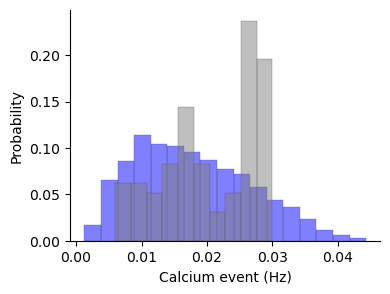

In [175]:
# Plot the distribution of event freqency
fig, ax = plt.subplots(figsize=(4,3), dpi=100)
sns.histplot(calcium_event_freq, binwidth=0.0025, stat='probability', kde=False, color='blue', alpha=.5, linewidth=0.2, edgecolor='.3');
sns.histplot(calcium_event_freq_sim, binwidth=0.0025, stat='probability', kde=False, color='gray', alpha=.5, linewidth=0.2, edgecolor='.3');
plt.xlabel('Calcium event (Hz)')
sns.despine()

In [176]:
# Calculate mean waveform
mean_waveforms_all = np.nanmean(mean_waveforms,axis=0)
mean_waveforms_sim_all = np.nanmean(mean_waveforms_sim,axis=0)
# Nomalize
mean_waveforms_all = MinMaxScaler(feature_range=(0, 1), copy=True).fit(mean_waveforms_all.reshape(-1,1)).transform(mean_waveforms_all.reshape(-1,1)).reshape(-1)
mean_waveforms_sim_all = MinMaxScaler(feature_range=(0, 1), copy=True).fit(mean_waveforms_sim_all.reshape(-1,1)).transform(mean_waveforms_sim_all.reshape(-1,1)).reshape(-1)

waveform correlation: 0.9331193301825995


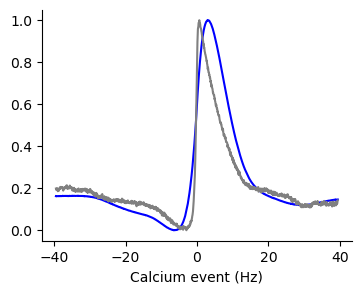

In [177]:
fig, ax = plt.subplots(figsize=(4,3), dpi=100)
plt.plot(time_waveform,mean_waveforms_all, color='blue')
plt.plot(time_waveform,mean_waveforms_sim_all, color='gray')
plt.xlabel('Calcium event (Hz)')
sns.despine()
print('waveform correlation:', np.corrcoef(mean_waveforms_all,mean_waveforms_sim_all)[0,1])

# Compare spike inference result

In [178]:
def plot_trace(t_imaging, t_ephys, dF_F, denoised, inf_spikes,true_spikes, threshold=0.2, xwindow=[0, 1000]):
    plt.figure(figsize=(10,3), tight_layout=True)
    plt.subplot(211)
    plt.plot(t_imaging, denoised, lw=1, label='denoised')
    plt.plot(t_imaging, dF_F, label='data', zorder=-12, c='y')
    plt.legend(ncol=3, frameon=False, loc=(.02,.9))
    plt.xlim(xwindow[0], xwindow[1])
    # plt.ylim(-0.5,5)
    simpleaxis(plt.gca())
    
    plt.subplot(212)
    spikes, _ = find_peaks(inf_spikes, height=threshold)
    num_inf_spikes = len(spikes)
    plt.plot(t_ephys, true_spikes+1.5, lw=1, label='true spike:'+str(len(np.where(true_spikes>0)[0])), c='black')
    plt.plot(t_imaging, inf_spikes, lw=1, label='deconvolved:'+str(num_inf_spikes), c='g')
    plt.hlines(xmin=xwindow[0], xmax=xwindow[1], y=threshold, color='red', lw=0.5, label='threhsold='+str(threshold))
    plt.ylim(0,3)
    plt.legend(ncol=3, frameon=False, loc=(.02,.9));
    simpleaxis(plt.gca())
    plt.xlim(xwindow[0], xwindow[1])
    plt.xlabel('Time (sec)')
 
    plt.subplots_adjust(wspace=0.4, hspace=0.6)

## Spike inference with OASIS AR1 model without baseline correction

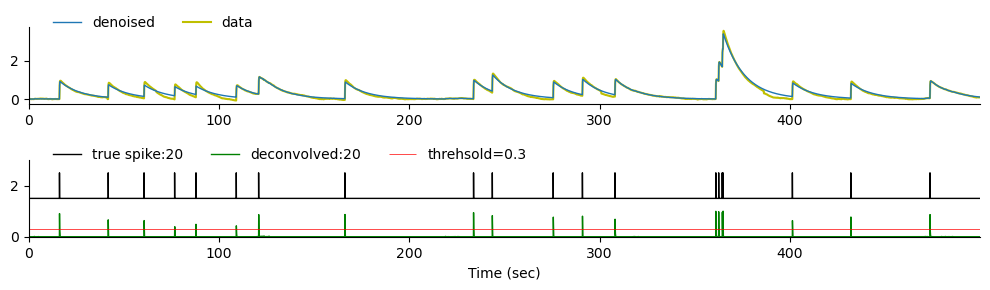

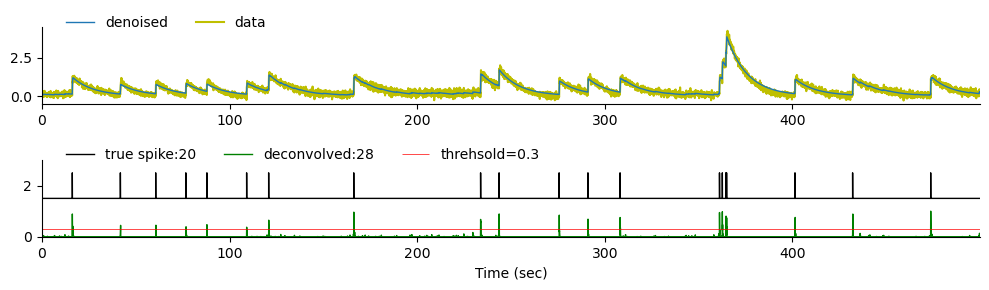

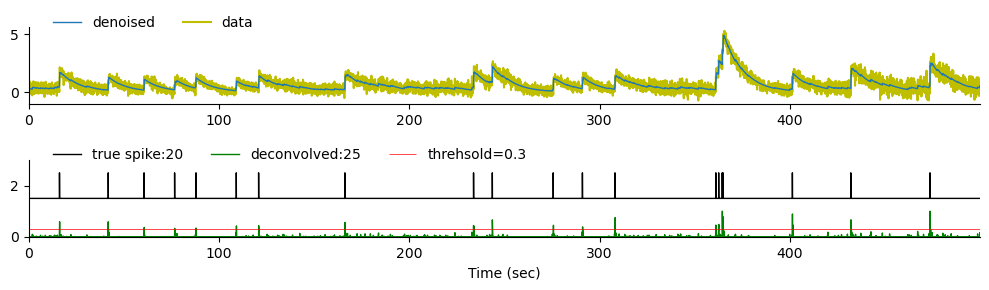

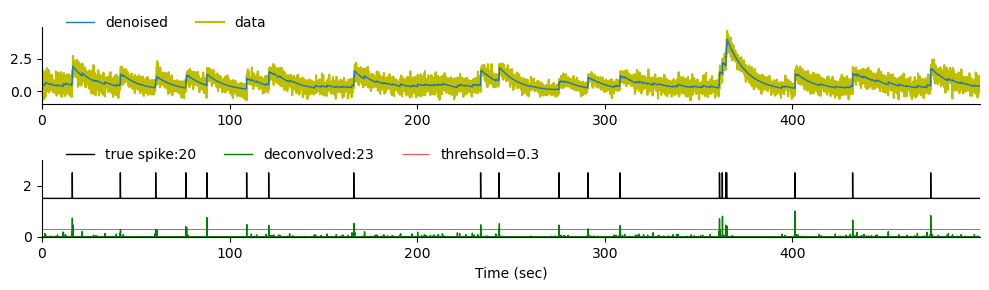

In [179]:
Cell_id=20
threshold=0.3 # threhsold for spike detection
for k in dF_F_sim_all.keys():
    denoised, inf_spikes = oasisAR1(dF_F_sim_all[k][Cell_id], 
                                    g=estimate_parameters(dF_F_sim_all[k][Cell_id], p=1)[0]) 
    inf_spikes=MinMaxScaler(feature_range=(0, 1), copy=True).fit(inf_spikes.reshape(-1,1)).transform(inf_spikes.reshape(-1,1)).reshape(-1)
    plot_trace(t_imaging, t_ephys, dF_F_sim_all[k][Cell_id], denoised, inf_spikes, Spike_train[Cell_id], 
               threshold=threshold, xwindow=[t_imaging.min(), t_imaging.max()])
    

CPU times: user 1.19 s, sys: 8 ms, total: 1.19 s
Wall time: 1.2 s


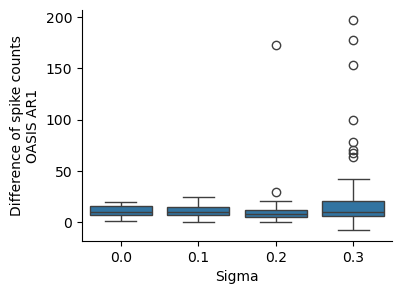

In [180]:
%%time
denoise_all={}
deconvo_all={}
for i in dF_F_sim_all.keys():
    denoise = []
    deconvo = []
    for v in range(dF_F_sim_all[i].shape[0]):
        c, s = oasisAR1(dF_F_sim_all[i][v], g=estimate_parameters(dF_F_sim_all[i][v], p=1)[0])
        denoise.append(c)
        deconvo.append(s)
    denoise=np.array(denoise)
    deconvo=np.array(deconvo)
    deconvo=MinMaxScaler(feature_range=(0, 1), copy=True).fit(deconvo.T).transform(deconvo.T).T
    denoise_all.update({i:denoise})
    deconvo_all.update({i:deconvo})

diff_spk_num_all = {}
for k in deconvo_all.keys() :
    spktiming = np.zeros(deconvo_all[k].shape)
    spktiming[np.where(deconvo_all[k]>threshold)]=1
    diff_spk_num = (np.sum(spktiming,axis=1)-np.sum(Spike_train,axis=1))
    diff_spk_num_all.update({k:diff_spk_num})
data = {'Key': [],'Value': []}
for key, values in diff_spk_num_all.items():
    data['Key'].extend([key] * len(values))
    data['Value'].extend(values)

df = pd.DataFrame(data)
# Seabornを使用してViolin plotを作成
plt.figure(figsize=(4, 3), dpi=100)
sns.boxplot(x='Key', y='Value', data=df)
# plt.ylim(-5,50)
plt.xlabel('Sigma')
plt.ylabel('Difference of spike counts\nOASIS AR1')
sns.despine()

## Spike inference with OASIS AR1 model with median baseline correction

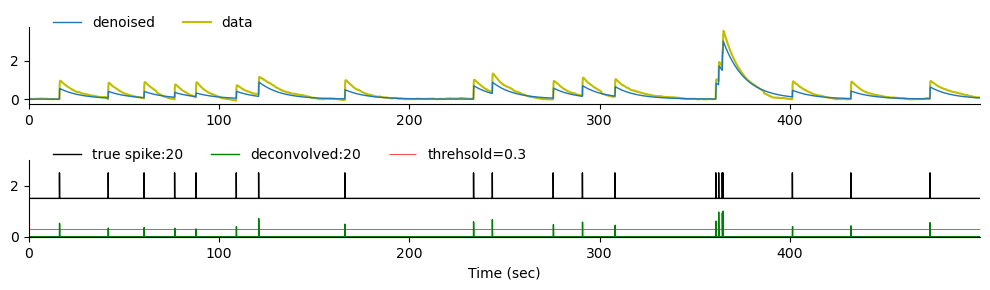

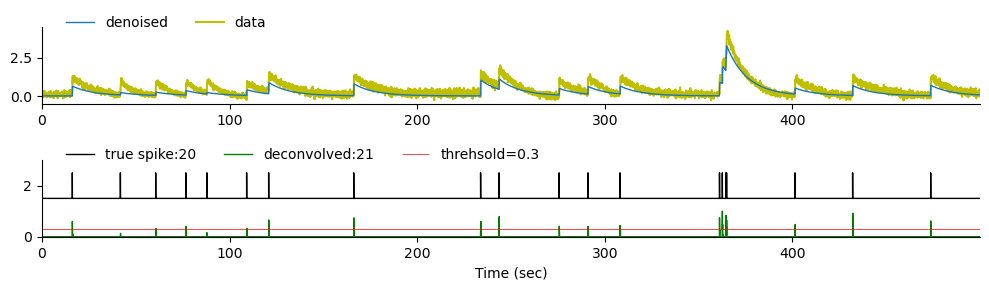

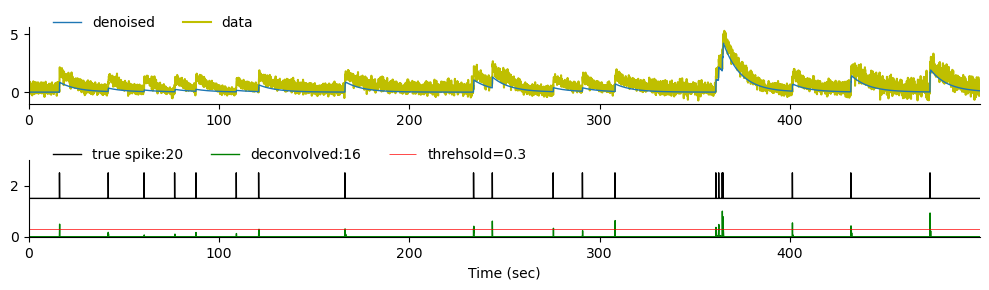

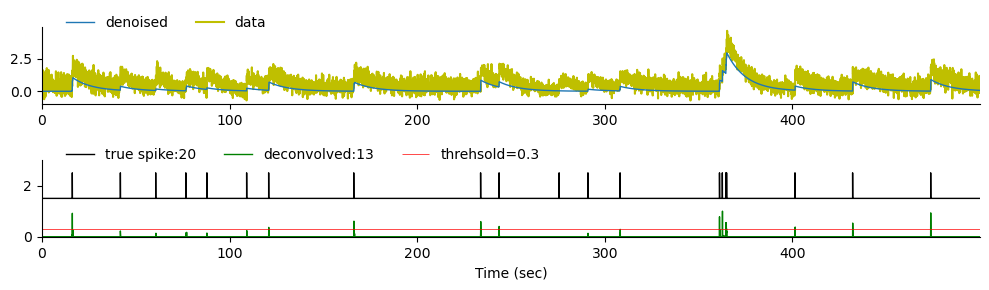

In [182]:
for k in dF_F_sim_all.keys():
    denoised, inf_spikes = oasisAR1(dF_F_sim_all[k][Cell_id]-np.median(dF_F_sim_all[k][Cell_id]), 
                                    g=estimate_parameters(dF_F_sim_all[k][Cell_id], p=1)[0]) 
    inf_spikes=MinMaxScaler(feature_range=(0, 1), copy=True).fit(inf_spikes.reshape(-1,1)).transform(inf_spikes.reshape(-1,1)).reshape(-1)
    plot_trace(t_imaging, t_ephys, dF_F_sim_all[k][Cell_id], denoised, inf_spikes, Spike_train[Cell_id], 
               threshold=threshold, xwindow=[t_imaging.min(), t_imaging.max()])

CPU times: user 1.22 s, sys: 16 ms, total: 1.24 s
Wall time: 1.24 s


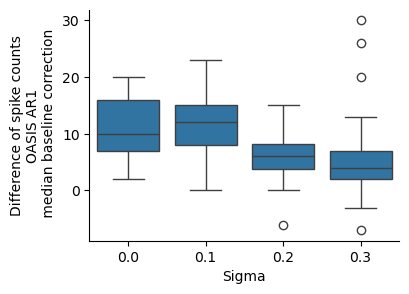

In [183]:
%%time
denoise_all={}
deconvo_all={}
for i in Fcorr_sim_all.keys():
    denoise = []
    deconvo = []
    median_trace = np.median(Fcorr_sim_all[i], axis=1)
    corrected_trace = Fcorr_sim_all[i]-median_trace.reshape(-1,1) # Baseline correction with median
    for v in range(Fcorr_sim_all[i].shape[0]):
        c, s = oasisAR1(corrected_trace[v], g=estimate_parameters(corrected_trace[v], p=1)[0])
        denoise.append(c)
        deconvo.append(s)
    denoise=np.array(denoise)
    deconvo=np.array(deconvo)
    deconvo=MinMaxScaler(feature_range=(0, 1), copy=True).fit(deconvo.T).transform(deconvo.T).T
    denoise_all.update({i:denoise})
    deconvo_all.update({i:deconvo})

diff_spk_num_all = {}
for k in deconvo_all.keys() :
    spktiming = np.zeros(deconvo_all[k].shape)
    spktiming[np.where(deconvo_all[k]>threshold)]=1
    diff_spk_num = (np.sum(spktiming,axis=1)-np.sum(Spike_train,axis=1))
    diff_spk_num_all.update({k:diff_spk_num})
data = {'Key': [],'Value': []}
for key, values in diff_spk_num_all.items():
    data['Key'].extend([key] * len(values))
    data['Value'].extend(values)

df = pd.DataFrame(data)
# Seabornを使用してViolin plotを作成
plt.figure(figsize=(4, 3), dpi=100)
sns.boxplot(x='Key', y='Value', data=df)
# plt.ylim(-5,50)
plt.xlabel('Sigma')
plt.ylabel('Difference of spike counts\nOASIS AR1\n median baseline correction')
sns.despine()

## Spike inference with OASIS AR1 model with suite2p based baseline correction

In [184]:
def baseline_corr(F, fs, baseline='maximin', sig_baseline = 10, win_baseline=60, prctile_baseline=15):
    '''
    From suite2p
    sig_baseline:in bins, standard deviation of gaussian with which to smooth
    win_baseline:in seconds, window in which to compute max/min filters
    '''
    from scipy.ndimage import maximum_filter1d, minimum_filter1d, gaussian_filter, percentile_filter
    win = int(win_baseline * fs)
    if baseline == "maximin":
        Flow = gaussian_filter(F, [0., sig_baseline])
        Flow = minimum_filter1d(Flow, win)
        Flow = maximum_filter1d(Flow, win)
    elif baseline == "constant":
        Flow = gaussian_filter(F, [0., sig_baseline])
        Flow = np.amin(Flow)
    elif baseline == "constant_prctile":
        Flow = np.percentile(F, prctile_baseline, axis=1)
        Flow = np.expand_dims(Flow, axis=1)
    elif baseline == "percentile":
        #cabsalculate baseline
        Flow = percentile_filter(F, percentile=prctile_baseline, size=win, axes=1)
    
    Fcorr = F - Flow
    
    return Fcorr

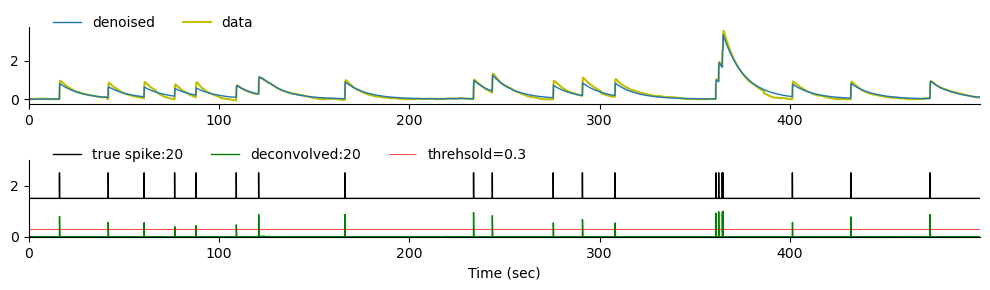

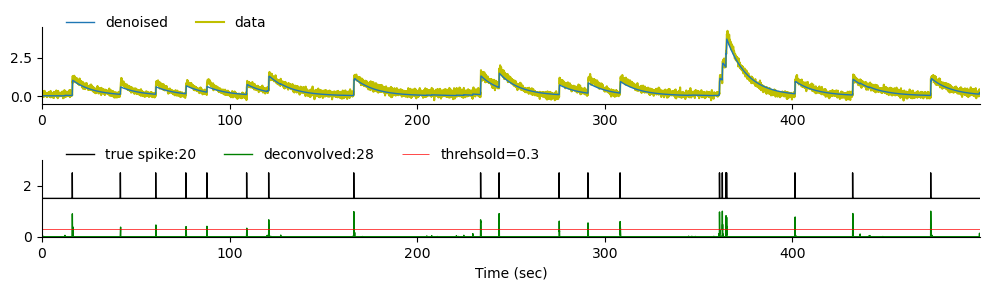

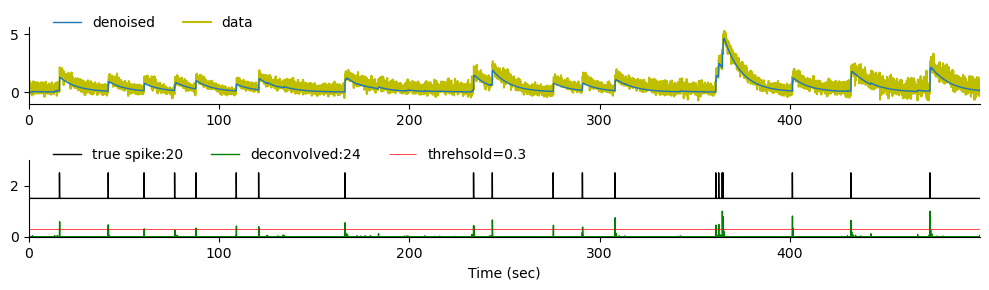

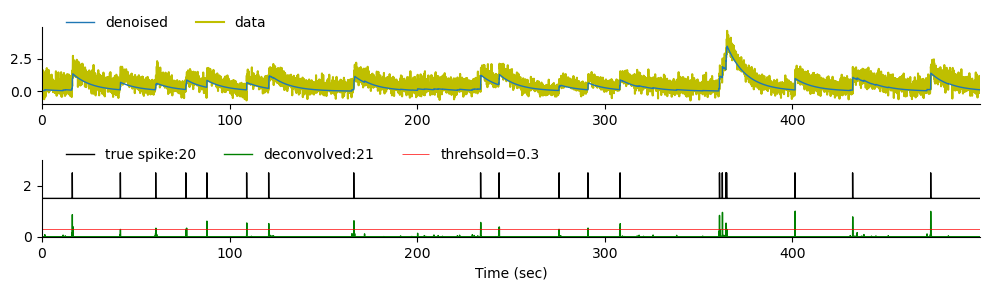

In [195]:
for k in dF_F_sim_all.keys():
    F_base_corr = baseline_corr(dF_F_sim_all[k], fs=sf_imaging, baseline='maximin', sig_baseline = 20, win_baseline=60, prctile_baseline=20)
    denoised, inf_spikes = oasisAR1(F_base_corr[Cell_id],
                    g=estimate_parameters(dF_F_sim_all[k][Cell_id], p=1)[0]) 
    inf_spikes=MinMaxScaler(feature_range=(0, 1), copy=True).fit(inf_spikes.reshape(-1,1)).transform(inf_spikes.reshape(-1,1)).reshape(-1)
    plot_trace(t_imaging, t_ephys, dF_F_sim_all[k][Cell_id], denoised, inf_spikes, Spike_train[Cell_id], 
               threshold=threshold, xwindow=[t_imaging.min(), t_imaging.max()])

    # plot_trace(t_imaging, t_ephys, dF_F_sim_all[k][Cell_id], denoised, inf_spikes, Spike_train[Cell_id], 
    #            threshold=threshold, xwindow=[0, 100])
    

CPU times: user 2.02 s, sys: 2.04 ms, total: 2.02 s
Wall time: 2.02 s


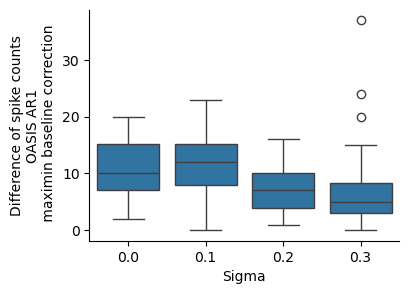

In [186]:
%%time
denoise_all={}
deconvo_all={}
for i in Fcorr_sim_all.keys():
    denoise = []
    deconvo = []
    corrected_trace = baseline_corr(Fcorr_sim_all[i], fs=sf_imaging, baseline='maximin', sig_baseline = 60, win_baseline=60, prctile_baseline=20)
    for v in range(Fcorr_sim_all[i].shape[0]):
        c, s = oasisAR1(corrected_trace[v], g=estimate_parameters(corrected_trace[v], p=1)[0])
        denoise.append(c)
        deconvo.append(s)
    denoise=np.array(denoise)
    deconvo=np.array(deconvo)
    deconvo=MinMaxScaler(feature_range=(0, 1), copy=True).fit(deconvo.T).transform(deconvo.T).T
    denoise_all.update({i:denoise})
    deconvo_all.update({i:deconvo})

diff_spk_num_all = {}
for k in deconvo_all.keys() :
    spktiming = np.zeros(deconvo_all[k].shape)
    spktiming[np.where(deconvo_all[k]>threshold)]=1
    diff_spk_num = (np.sum(spktiming,axis=1)-np.sum(Spike_train,axis=1))
    diff_spk_num_all.update({k:diff_spk_num})
data = {'Key': [],'Value': []}
for key, values in diff_spk_num_all.items():
    data['Key'].extend([key] * len(values))
    data['Value'].extend(values)

df = pd.DataFrame(data)
# Seabornを使用してViolin plotを作成
plt.figure(figsize=(4, 3), dpi=100)
sns.boxplot(x='Key', y='Value', data=df)
# plt.ylim(-5,50)
plt.xlabel('Sigma')
plt.ylabel('Difference of spike counts\nOASIS AR1\n maximin baseline correction')
sns.despine()

CPU times: user 1.97 s, sys: 927 µs, total: 1.97 s
Wall time: 1.97 s


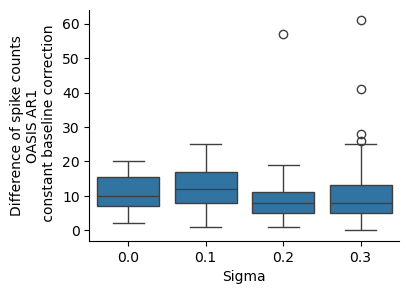

In [187]:
%%time
denoise_all={}
deconvo_all={}
for i in Fcorr_sim_all.keys():
    denoise = []
    deconvo = []
    corrected_trace = baseline_corr(Fcorr_sim_all[i], fs=sf_imaging, baseline='constant', sig_baseline = 60, win_baseline=60, prctile_baseline=20)
    for v in range(Fcorr_sim_all[i].shape[0]):
        c, s = oasisAR1(corrected_trace[v], g=estimate_parameters(corrected_trace[v], p=1)[0])
        denoise.append(c)
        deconvo.append(s)
    denoise=np.array(denoise)
    deconvo=np.array(deconvo)
    deconvo=MinMaxScaler(feature_range=(0, 1), copy=True).fit(deconvo.T).transform(deconvo.T).T
    denoise_all.update({i:denoise})
    deconvo_all.update({i:deconvo})

diff_spk_num_all = {}
for k in deconvo_all.keys() :
    spktiming = np.zeros(deconvo_all[k].shape)
    spktiming[np.where(deconvo_all[k]>threshold)]=1
    diff_spk_num = (np.sum(spktiming,axis=1)-np.sum(Spike_train,axis=1))
    diff_spk_num_all.update({k:diff_spk_num})
data = {'Key': [],'Value': []}
for key, values in diff_spk_num_all.items():
    data['Key'].extend([key] * len(values))
    data['Value'].extend(values)

df = pd.DataFrame(data)
# Seabornを使用してViolin plotを作成
plt.figure(figsize=(4, 3), dpi=100)
sns.boxplot(x='Key', y='Value', data=df)
# plt.ylim(-5,50)
plt.xlabel('Sigma')
plt.ylabel('Difference of spike counts\nOASIS AR1\n constant baseline correction')
sns.despine()

CPU times: user 1.22 s, sys: 956 µs, total: 1.22 s
Wall time: 1.22 s


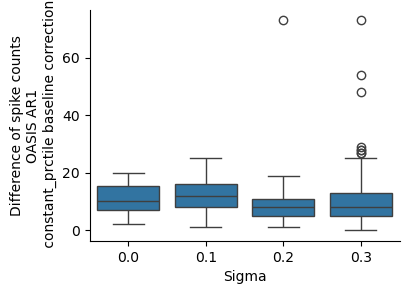

In [188]:
%%time
denoise_all={}
deconvo_all={}
for i in Fcorr_sim_all.keys():
    denoise = []
    deconvo = []
    corrected_trace = baseline_corr(Fcorr_sim_all[i], fs=sf_imaging, baseline='constant_prctile', sig_baseline = 60, win_baseline=60, prctile_baseline=20)
    for v in range(Fcorr_sim_all[i].shape[0]):
        c, s = oasisAR1(corrected_trace[v], g=estimate_parameters(corrected_trace[v], p=1)[0])
        denoise.append(c)
        deconvo.append(s)
    denoise=np.array(denoise)
    deconvo=np.array(deconvo)
    deconvo=MinMaxScaler(feature_range=(0, 1), copy=True).fit(deconvo.T).transform(deconvo.T).T
    denoise_all.update({i:denoise})
    deconvo_all.update({i:deconvo})

diff_spk_num_all = {}
for k in deconvo_all.keys() :
    spktiming = np.zeros(deconvo_all[k].shape)
    spktiming[np.where(deconvo_all[k]>threshold)]=1
    diff_spk_num = (np.sum(spktiming,axis=1)-np.sum(Spike_train,axis=1))
    diff_spk_num_all.update({k:diff_spk_num})
data = {'Key': [],'Value': []}
for key, values in diff_spk_num_all.items():
    data['Key'].extend([key] * len(values))
    data['Value'].extend(values)

df = pd.DataFrame(data)
# Seabornを使用してViolin plotを作成
plt.figure(figsize=(4, 3), dpi=100)
sns.boxplot(x='Key', y='Value', data=df)
# plt.ylim(-5,50)
plt.xlabel('Sigma')
plt.ylabel('Difference of spike counts\nOASIS AR1\n constant_prctile baseline correction')
sns.despine()

CPU times: user 23.7 s, sys: 14.3 ms, total: 23.7 s
Wall time: 23.8 s


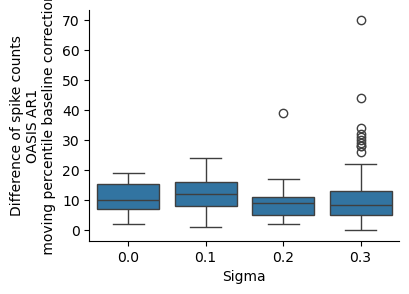

In [189]:
%%time
denoise_all={}
deconvo_all={}
for i in Fcorr_sim_all.keys():
    denoise = []
    deconvo = []
    corrected_trace = baseline_corr(Fcorr_sim_all[i], fs=sf_imaging, baseline='percentile', sig_baseline = 60, win_baseline=60, prctile_baseline=20)
    for v in range(Fcorr_sim_all[i].shape[0]):
        c, s = oasisAR1(corrected_trace[v], g=estimate_parameters(corrected_trace[v], p=1)[0])
        denoise.append(c)
        deconvo.append(s)
    denoise=np.array(denoise)
    deconvo=np.array(deconvo)
    deconvo=MinMaxScaler(feature_range=(0, 1), copy=True).fit(deconvo.T).transform(deconvo.T).T
    denoise_all.update({i:denoise})
    deconvo_all.update({i:deconvo})

diff_spk_num_all = {}
for k in deconvo_all.keys() :
    spktiming = np.zeros(deconvo_all[k].shape)
    spktiming[np.where(deconvo_all[k]>threshold)]=1
    diff_spk_num = (np.sum(spktiming,axis=1)-np.sum(Spike_train,axis=1))
    diff_spk_num_all.update({k:diff_spk_num})
data = {'Key': [],'Value': []}
for key, values in diff_spk_num_all.items():
    data['Key'].extend([key] * len(values))
    data['Value'].extend(values)

df = pd.DataFrame(data)
# Seabornを使用してViolin plotを作成
plt.figure(figsize=(4, 3), dpi=100)
sns.boxplot(x='Key', y='Value', data=df)
# plt.ylim(-5,50)
plt.xlabel('Sigma')
plt.ylabel('Difference of spike counts\nOASIS AR1\n moving percentile baseline correction')
sns.despine()

## Original suite2p deconvolution

In [190]:
# baseline operation
Fc_all={}
for k in Fcorr_sim_all.keys():
    Fc = dcnv.preprocess(
         # F=Ca_dynamics_all[k],
         F=Fcorr_sim_all[k],
         baseline='maximin', # take the running max of the running min after smoothing with gaussian
         win_baseline=60, # in seconds, window in which to compute max/min filters
         sig_baseline=60, # in bins, standard deviation of gaussian with which to smooth
         fs=sf_imaging,
         prctile_baseline=20
     )
    Fc_all.update({k:Fc})
# get spikes
deconvo_all = {}
for k in Ca_dynamics_all.keys() :
    deconvo = dcnv.oasis(F=Fc_all[k], batch_size=100, tau=10, fs=sf_imaging)
    deconvo = MinMaxScaler(feature_range=(0, 1), copy=True).fit(deconvo.T).transform(deconvo.T).T
    deconvo_all.update({k:deconvo})

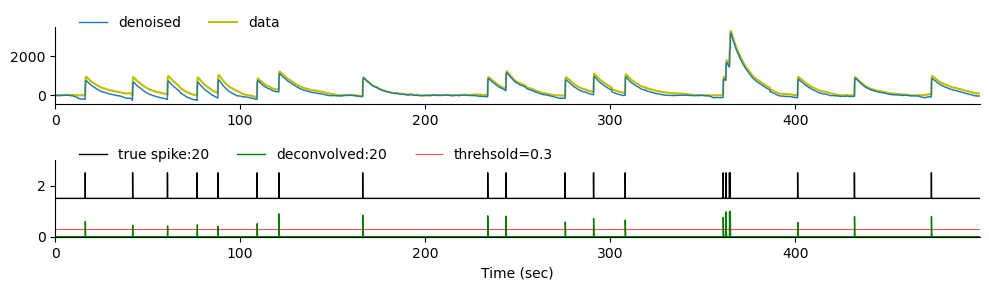

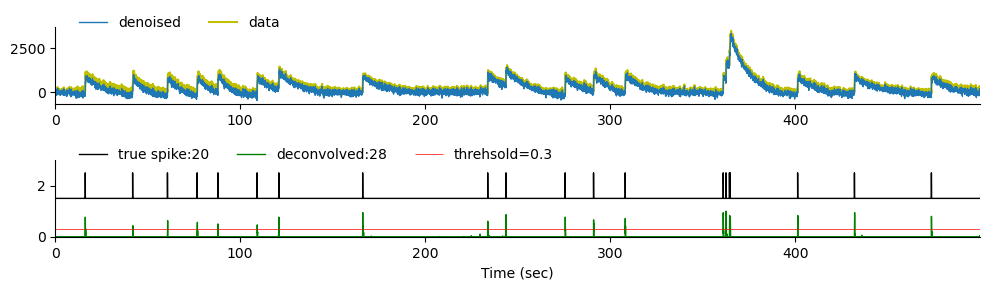

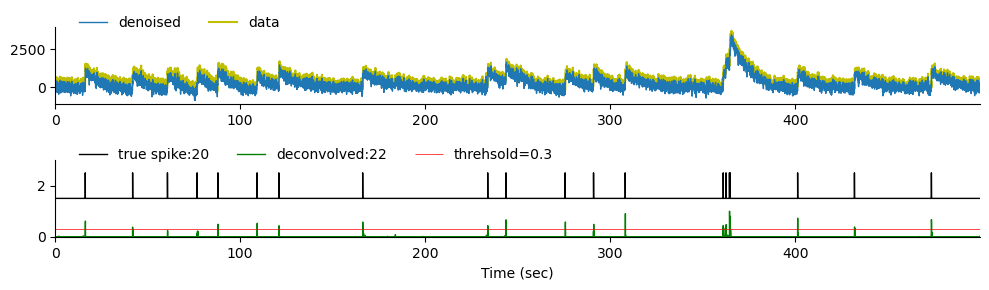

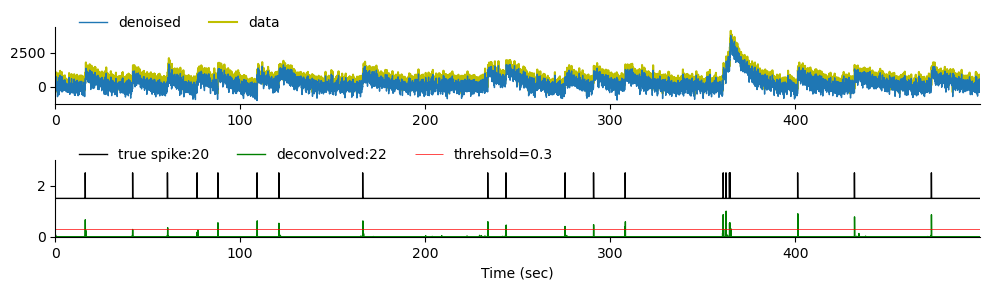

In [191]:
for k in Fcorr_sim_all.keys():
    plot_trace(t_imaging, t_ephys, Fcorr_sim_all[k][Cell_id], Fc_all[k][Cell_id], deconvo_all[k][Cell_id], Spike_train[Cell_id], 
           threshold=threshold, xwindow=[t_imaging.min(), t_imaging.max()])
    

CPU times: user 4.74 s, sys: 16.6 ms, total: 4.76 s
Wall time: 1.65 s


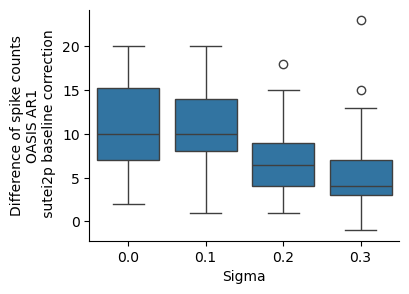

In [192]:
%%time
# baseline operation
Fc_all={}
for k in Fcorr_sim_all.keys():
    Fc = dcnv.preprocess(
         # F=Ca_dynamics_all[k],
         F=Fcorr_sim_all[k],
         baseline='maximin', # take the running max of the running min after smoothing with gaussian
         win_baseline=60, # in seconds, window in which to compute max/min filters
         sig_baseline=60, # in bins, standard deviation of gaussian with which to smooth
         fs=sf_imaging,
         prctile_baseline=20
     )
    Fc_all.update({k:Fc})
# get spikes
deconvo_all = {}
for k in Ca_dynamics_all.keys() :
    deconvo = dcnv.oasis(F=Fc_all[k], batch_size=100, tau=10, fs=sf_imaging)
    deconvo = MinMaxScaler(feature_range=(0, 1), copy=True).fit(deconvo.T).transform(deconvo.T).T
    deconvo_all.update({k:deconvo})

diff_spk_num_all = {}
for k in deconvo_all.keys() :
    spktiming = np.zeros(deconvo_all[k].shape)
    spktiming[np.where(deconvo_all[k]>threshold)]=1
    diff_spk_num = (np.sum(spktiming,axis=1)-np.sum(Spike_train,axis=1))
    diff_spk_num_all.update({k:diff_spk_num})
data = {'Key': [],'Value': []}
for key, values in diff_spk_num_all.items():
    data['Key'].extend([key] * len(values))
    data['Value'].extend(values)

df = pd.DataFrame(data)
# Seabornを使用してViolin plotを作成
plt.figure(figsize=(4, 3), dpi=100)
sns.boxplot(x='Key', y='Value', data=df)
# plt.ylim(-5,50)
plt.xlabel('Sigma')
plt.ylabel('Difference of spike counts\nOASIS AR1\n sutei2p baseline correction')
sns.despine()